In [57]:
# load and plot dataset
from pandas import read_excel
from pandas import read_csv
from pandas import datetime
import pandas as pd
from matplotlib import pyplot


# load dataset
series = read_csv('energydata_complete.csv', squeeze=True)

series.head()


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [58]:
series['Windspeed'].describe()

count    19735.000000
mean         4.039752
std          2.451221
min          0.000000
25%          2.000000
50%          3.666667
75%          5.500000
max         14.000000
Name: Windspeed, dtype: float64

In [59]:
print(series.shape)

(19735, 29)


In [60]:
series['date'] = pd.to_datetime(series['date'])

In [61]:
series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
date           19735 non-null datetime64[ns]
Appliances     19735 non-null int64
lights         19735 non-null int64
T1             19735 non-null float64
RH_1           19735 non-null float64
T2             19735 non-null float64
RH_2           19735 non-null float64
T3             19735 non-null float64
RH_3           19735 non-null float64
T4             19735 non-null float64
RH_4           19735 non-null float64
T5             19735 non-null float64
RH_5           19735 non-null float64
T6             19735 non-null float64
RH_6           19735 non-null float64
T7             19735 non-null float64
RH_7           19735 non-null float64
T8             19735 non-null float64
RH_8           19735 non-null float64
T9             19735 non-null float64
RH_9           19735 non-null float64
T_out          19735 non-null float64
Press_mm_hg    19735 non-null float64
RH_out        

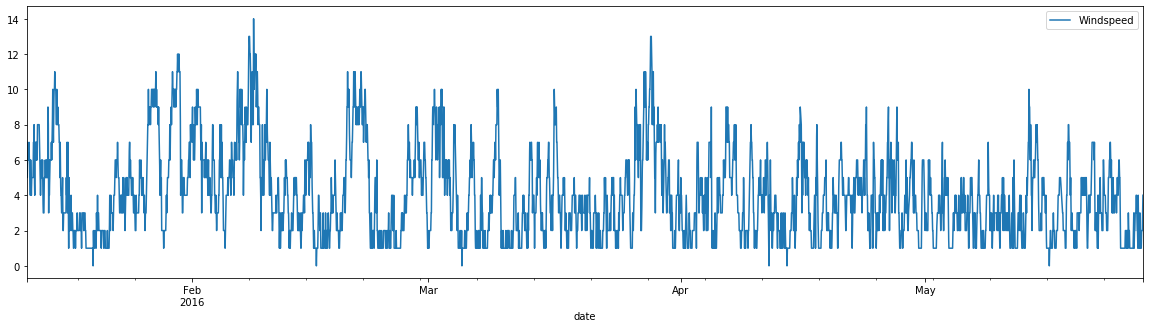

In [62]:
# line plot
series.plot('date', 'Windspeed', figsize=(20,5))
pyplot.show()

# LSTM Model Development

In [63]:
series.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [64]:
series['Windspeed'].values

array([7.        , 6.66666667, 6.33333333, ..., 3.66666667, 3.83333333,
       4.        ])

In [65]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from math import sqrt
from matplotlib import pyplot
from sklearn.preprocessing import MinMaxScaler
import numpy
from pandas import Series
from pandas import DataFrame
from pandas import concat
from keras.optimizers import Adam
from keras.layers import Dropout
import numpy as np

# create a differenced series
def difference(dataset, interval=1):
	diff = list()
	for i in range(interval, len(dataset)):
		value = dataset[i] - dataset[i - interval]
		diff.append(value)
	return Series(diff)

# # transform data to be stationary
raw_values = series['Windspeed'].values
diff_values = difference(raw_values, 1)
print(diff_values)

0       -0.333333
1       -0.333333
2       -0.333333
3       -0.333333
4       -0.333333
           ...   
19729    0.166667
19730    0.166667
19731    0.166667
19732    0.166667
19733    0.166667
Length: 19734, dtype: float64


In [66]:
# frame a sequence as a supervised learning problem
def timeseries_to_supervised(data, lag=1):
	df = DataFrame(data)
	columns = [df.shift(i) for i in range(1, lag+1)]
	columns.append(df)
	df = concat(columns, axis=1)
	df.fillna(0, inplace=True)
	return df

# transform data to be supervised learning
supervised = timeseries_to_supervised(diff_values, 1)
supervised_values = supervised.values
supervised

,0,0
0,0.000000,-0.333333
1,-0.333333,-0.333333
2,-0.333333,-0.333333
3,-0.333333,-0.333333
4,-0.333333,-0.333333
...,...,...
19729,0.166667,0.166667
19730,0.166667,0.166667
19731,0.166667,0.166667
19732,0.166667,0.166667


In [67]:
# split data into train and test-sets
train, test = supervised_values[0:-109], supervised_values[-109:]
print(train)

[[ 0.         -0.33333333]
 [-0.33333333 -0.33333333]
 [-0.33333333 -0.33333333]
 ...
 [-0.16666667 -0.16666667]
 [-0.16666667 -0.16666667]
 [-0.16666667 -0.16666667]]


In [68]:
# scale train and test data to [-1, 1] (tanh)
def scale(train, test):
	# fit scaler
	scaler = MinMaxScaler(feature_range=(-1, 1))
	scaler = scaler.fit(train)
	# transform train
	train = train.reshape(train.shape[0], train.shape[1])
	train_scaled = scaler.transform(train)
	# transform test
	test = test.reshape(test.shape[0], test.shape[1])
	test_scaled = scaler.transform(test)
	return scaler, train_scaled, test_scaled

# transform the scale of the data
scaler, train_scaled, test_scaled = scale(train, test)

Train on 19625 samples, validate on 19625 samples
Epoch 1/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0111 - val_loss: 0.0101
Epoch 2/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0106 - val_loss: 0.0102
Epoch 3/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0105 - val_loss: 0.0096
Epoch 4/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0094 - val_loss: 0.0089
Epoch 5/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 6/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 7/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0103 - val_loss: 0.0091
Epoch 8/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0094 - val_loss: 0.0094
Epoch 9/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0095 - val_

19625/19625 [==============================] - 31s 2ms/step - loss: 0.0076 - val_loss: 0.0073
Epoch 77/1500
19625/19625 [==============================] - 29s 2ms/step - loss: 0.0077 - val_loss: 0.0074
Epoch 78/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 79/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0075 - val_loss: 0.0072
Epoch 80/1500
19625/19625 [==============================] - 33s 2ms/step - loss: 0.0079 - val_loss: 0.0073
Epoch 81/1500
19625/19625 [==============================] - 33s 2ms/step - loss: 0.0081 - val_loss: 0.0077
Epoch 82/1500
19625/19625 [==============================] - 32s 2ms/step - loss: 0.0078 - val_loss: 0.0073
Epoch 83/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 84/1500
19625/19625 [==============================] - 29s 2ms/step - loss: 0.0082 - val_loss: 0.0080
Epoch 85/1500
19625/19625 [===============

19625/19625 [==============================] - 29s 2ms/step - loss: 0.0060 - val_loss: 0.0053
Epoch 152/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 153/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 154/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0060 - val_loss: 0.0058
Epoch 155/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0060 - val_loss: 0.0056
Epoch 156/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0060 - val_loss: 0.0053
Epoch 157/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 158/1500
19625/19625 [==============================] - 27s 1ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 159/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0059 - val_loss: 0.0054
Epoch 160/1500
19625/19625 [======

19625/19625 [==============================] - 28s 1ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 227/1500
19625/19625 [==============================] - 31s 2ms/step - loss: 0.0059 - val_loss: 0.0084
Epoch 228/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 229/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0070 - val_loss: 0.0061
Epoch 230/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0086 - val_loss: 0.0074
Epoch 231/1500
19625/19625 [==============================] - 32s 2ms/step - loss: 0.0079 - val_loss: 0.0069
Epoch 232/1500
19625/19625 [==============================] - 32s 2ms/step - loss: 0.0103 - val_loss: 0.0105
Epoch 233/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0091 - val_loss: 0.0081
Epoch 234/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0079 - val_loss: 0.0067
Epoch 235/1500
19625/19625 [======

19625/19625 [==============================] - 29s 1ms/step - loss: 0.0072 - val_loss: 0.0067
Epoch 302/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0076 - val_loss: 0.0072
Epoch 303/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0079 - val_loss: 0.0075
Epoch 304/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0081 - val_loss: 0.0073
Epoch 305/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0078 - val_loss: 0.0071
Epoch 306/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0076 - val_loss: 0.0071
Epoch 307/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0082 - val_loss: 0.0074
Epoch 308/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0079 - val_loss: 0.0068
Epoch 309/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0078 - val_loss: 0.0070
Epoch 310/1500
19625/19625 [======

...

19625/19625 [==============================] - 29s 1ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 1200/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 1201/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 1202/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 1203/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 1204/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0064 - val_loss: 0.0054
Epoch 1205/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0066 - val_loss: 0.0059
Epoch 1206/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0064 - val_loss: 0.0055
Epoch 1207/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 1208/1500
19625/1962

19625/19625 [==============================] - 28s 1ms/step - loss: 0.0064 - val_loss: 0.0058
Epoch 1274/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 1275/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 1276/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 1277/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 1278/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 1279/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0063 - val_loss: 0.0054
Epoch 1280/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0062 - val_loss: 0.0054
Epoch 1281/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 1282/1500
19625/1962

19625/19625 [==============================] - 36s 2ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 1348/1500
19625/19625 [==============================] - 27s 1ms/step - loss: 0.0065 - val_loss: 0.0057
Epoch 1349/1500
19625/19625 [==============================] - 27s 1ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 1350/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 1351/1500
19625/19625 [==============================] - 27s 1ms/step - loss: 0.0062 - val_loss: 0.0056
Epoch 1352/1500
19625/19625 [==============================] - 28s 1ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 1353/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 1354/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0070 - val_loss: 0.0068
Epoch 1355/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0067 - val_loss: 0.0057
Epoch 1356/1500
19625/1962

19625/19625 [==============================] - 29s 1ms/step - loss: 0.0066 - val_loss: 0.0058
Epoch 1422/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0065 - val_loss: 0.0057
Epoch 1423/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 1424/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0063 - val_loss: 0.0061
Epoch 1425/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 1426/1500
19625/19625 [==============================] - 31s 2ms/step - loss: 0.0065 - val_loss: 0.0055
Epoch 1427/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 1428/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0062 - val_loss: 0.0054
Epoch 1429/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0062 - val_loss: 0.0055
Epoch 1430/1500
19625/1962

19625/19625 [==============================] - 30s 2ms/step - loss: 0.0078 - val_loss: 0.0065
Epoch 1496/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0073 - val_loss: 0.0061
Epoch 1497/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0076 - val_loss: 0.0077
Epoch 1498/1500
19625/19625 [==============================] - 30s 2ms/step - loss: 0.0085 - val_loss: 0.0071
Epoch 1499/1500
19625/19625 [==============================] - 29s 1ms/step - loss: 0.0082 - val_loss: 0.0075
Epoch 1500/1500
19625/19625 [==============================] - 31s 2ms/step - loss: 0.0077 - val_loss: 0.0069
mean = 0.007
max = 0.011
min = 0.006


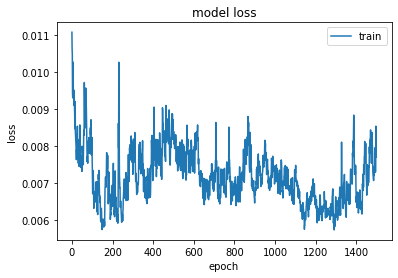

array([[ 0.06322801],
       [-0.17363417],
       [-0.19682735],
       ...,
       [-0.05673494],
       [-0.05619545],
       [-0.03281695]], dtype=float32)

In [69]:
# fit an LSTM network to training data
def fit_lstm(train, batch_size, nb_epoch, neurons):
	X, y = train[:, 0:-1], train[:, -1]
	X = X.reshape(X.shape[0], 1, X.shape[1])
	model = Sequential()
	model.add(LSTM(neurons, batch_input_shape=(batch_size, X.shape[1], X.shape[2]), stateful=True))
	model.add(Dropout(0.2))
	model.add(Dense(1))
	model.compile(loss='mean_squared_error', optimizer='adam')
	history =model.fit(X, y, epochs=nb_epoch, batch_size=batch_size, validation_data=(X, y), shuffle=False)
	print("mean = %.3f" % np.mean(history.history['loss']))
	print("max = %.3f" % np.max(history.history['loss']))
	print("min = %.3f" % np.min(history.history['loss']))
    # summarize history for loss
	pyplot.plot(history.history['loss'])
	pyplot.title('model loss')
	pyplot.ylabel('loss')
	pyplot.xlabel('epoch')
	pyplot.legend(['train'], loc='upper right')
	pyplot.show()
	return model

# fit the model
lstm_model = fit_lstm(train_scaled, 1, 1500, 50)
# forecast the entire training dataset to build up state for forecasting
train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
lstm_model.predict(train_reshaped, batch_size=1)


In [70]:
lstm_model.save_weights("model.h5")

In [71]:
lstm_model.summary()

Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_14 (LSTM)               (1, 50)                   10400     
_________________________________________________________________
dropout_14 (Dropout)         (1, 50)                   0         
_________________________________________________________________
dense_14 (Dense)             (1, 1)                    51        
Total params: 10,451
Trainable params: 10,451
Non-trainable params: 0
_________________________________________________________________


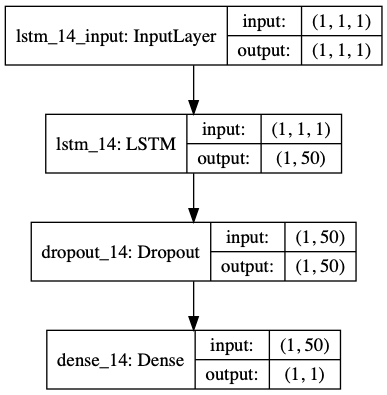

In [72]:
from keras.utils.vis_utils import plot_model
plot_model(lstm_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [73]:
# make a one-step forecast
def forecast_lstm(model, batch_size, X):
	X = X.reshape(1, 1, len(X))
	yhat = model.predict(X, batch_size=batch_size)
	return yhat[0,0]

# inverse scaling for a forecasted value
def invert_scale(scaler, X, value):
	new_row = [x for x in X] + [value]
	array = numpy.array(new_row)
	array = array.reshape(1, len(array))
	inverted = scaler.inverse_transform(array)
	return inverted[0, -1]

# invert differenced value
def inverse_difference(history, yhat, interval=1):
	return yhat + history[-interval]

# walk-forward validation on the test data
predictions = list()
for i in range(len(test_scaled)):
	# make one-step forecast
	X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
	yhat = forecast_lstm(lstm_model, 1, X)
	# invert scaling
	yhat = invert_scale(scaler, X, yhat)
	# invert differencing
	yhat = inverse_difference(raw_values, yhat, len(test_scaled)+1-i)
	# store forecast
	predictions.append(yhat)
	expected = raw_values[len(train) + i + 1]
	print('%d0 minutes, Predicted=%f, Expected=%f' % (i+1, yhat, expected))

10 minutes, Predicted=3.094501, Expected=3.000000
20 minutes, Predicted=2.942368, Expected=2.833333
30 minutes, Predicted=2.731946, Expected=2.666667
40 minutes, Predicted=2.523814, Expected=2.500000
50 minutes, Predicted=2.356136, Expected=2.333333
60 minutes, Predicted=2.220459, Expected=2.166667
70 minutes, Predicted=2.090139, Expected=2.000000
80 minutes, Predicted=1.945781, Expected=2.000000
90 minutes, Predicted=2.003703, Expected=2.000000
100 minutes, Predicted=2.008086, Expected=2.000000
110 minutes, Predicted=1.998899, Expected=2.000000
120 minutes, Predicted=2.004703, Expected=2.000000
130 minutes, Predicted=2.005202, Expected=2.000000
140 minutes, Predicted=2.004932, Expected=1.833333
150 minutes, Predicted=1.695916, Expected=1.666667
160 minutes, Predicted=1.521722, Expected=1.500000
170 minutes, Predicted=1.355752, Expected=1.333333
180 minutes, Predicted=1.214321, Expected=1.166667
190 minutes, Predicted=1.094554, Expected=1.000000
200 minutes, Predicted=0.942486, Expecte

In [74]:
series.date[-109:].dt.minute.describe()

count    109.000000
mean      24.770642
std       17.245307
min        0.000000
25%       10.000000
50%       20.000000
75%       40.000000
max       50.000000
Name: date, dtype: float64

Test RMSE:  0.095491


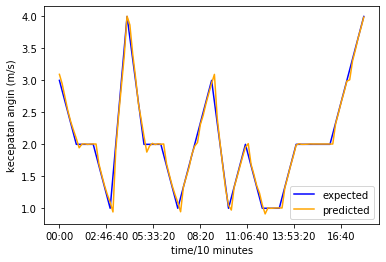

In [75]:
from sklearn.metrics import mean_squared_error

# report performance
rmse = sqrt(mean_squared_error(raw_values[-109:], predictions))
print('Test RMSE: % f' % rmse)
# line plot of observed vs predicted
pyplot.plot(series.date[-109:].dt.time,raw_values[-109:],color='blue', label = 'expected')
pyplot.plot(series.date[-109:].dt.time,predictions,color='orange', label = 'predicted')
pyplot.xlabel("time/10 minutes")
pyplot.ylabel("kecepatan angin (m/s)")
pyplot.legend()
pyplot.show()


Test RMSE:  0.095491


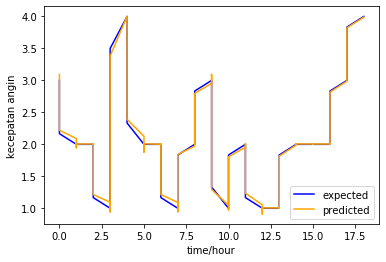

In [76]:
# report performance
rmse = sqrt(mean_squared_error(raw_values[-109:], predictions))
print('Test RMSE: % f' % rmse)
# line plot of observed vs predicted
pyplot.plot(series.date[-109:].dt.hour,raw_values[-109:],color='blue', label = 'expected')
pyplot.plot(series.date[-109:].dt.hour,predictions,color='orange', label = 'predicted')
pyplot.xlabel("time/hour")
pyplot.ylabel("kecepatan angin")
pyplot.legend()
pyplot.show()

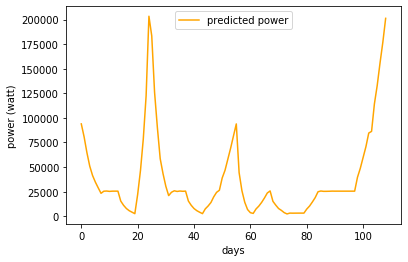

Total power=  4177448.821680647 watt


In [77]:
radius = 58 #meter
air_density = 1.2 #kg/m³
efficiency_factor = 0.5
power = 3.14/2 * pow(radius, 2) * np.power(predictions, 3) * air_density * efficiency_factor

pyplot.plot(power,color='orange', label = 'predicted power')
pyplot.xlabel("days")
pyplot.ylabel("power (watt)")
pyplot.legend()
pyplot.show()
print("Total power= " ,power.sum(), "watt")